In [1]:
import h5py
import numpy as np
import torch
import os
import numpy as np
import sigpy.mri as spmri
import sigpy as sp

# --- Optional CuPy import + capability check ---
try:
    import cupy as cp
    _cupy_ok = True
    try:
        _gpu_count = cp.cuda.runtime.getDeviceCount()
        _cupy_ok = _gpu_count > 0
    except Exception:
        _cupy_ok = False
except Exception:
    cp = None
    _cupy_ok = False

from utils.show_slice import show_slice, show_kspace_slice, header_info
from utils.fftnc import fftnc, ifftnc # normalised fft and ifft for n dimensions
from utils.espiritmaps import calc_espirit_maps, to_espirit_dims, from_espirit_dims

# Get all .h5 files from the specified folder
folder = "/home/henri/Desktop/FastMRIhdata/t1/test"

# Set device for SigPy and PyTorch 
sp_device = sp.Device(0) if _cupy_ok else sp.Device(-1)
device = torch.device("cuda:0" if _cupy_ok and torch.cuda.is_available() else "cpu")

h5_files = [f for f in os.listdir(folder) if f.endswith(".h5")]
h5_files.sort() 

path = os.path.join(folder, h5_files[3])

with h5py.File(path, "r") as f:
    numpy_kspace = f["kspace"][:] 
    header_bytes = f["ismrmrd_header"][()]  
    header_str = header_bytes.decode("utf-8")

header_info(header_str)

kspace = torch.from_numpy(numpy_kspace) # slices, coils, height, width
nSlices, nCha, nY, nX = kspace.shape
image_shape = nY, nX, 1, nCha

kspace = kspace.permute(1, 2, 3, 0).contiguous()  # coils, height, width, slices

kspace = kspace[:,:,:,5].unsqueeze(-1).to(device)  # Take only one slice for testing #188:452

/home/henri/miniforge3/envs/MRI/lib/python3.13/site-packages/sigpy/config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
No module named 'cupyx.cudnn'
  warnings.warn(


Protocol: AX T1_FBB
Scanner: SIEMENS Skyra 2.8936 T
Coils: 20
Matrix: 640 x 320
FOV: 440 mm x 220 mm
TR: 250 ms
TE: 3.4 ms


EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

/home/henri/miniforge3/envs/MRI/lib/python3.13/site-packages/sigpy/pytorch.py:39: VisibleDeprecationWarning: This function is deprecated and will be removed in a future release. Use the cupy.from_dlpack() array constructor instead.
  tensor = from_dlpack(array.toDlpack())


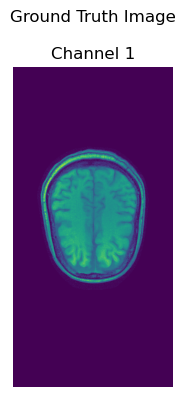

In [2]:
espirit_maps = from_espirit_dims(calc_espirit_maps(kspace, acs = 48, kernel_width=12, sp_device=sp_device)) # width, height, slices, coils
kspace_img = from_espirit_dims(kspace)  # width, height, slices, coils
img_cplx = ifftnc(kspace_img, dims=(-4, -3, -2))
p_true = torch.sum(img_cplx*espirit_maps.conj(), dim=-1).to(device)  # Ground truth image
show_slice(p_true, max_images=1, headline="Ground Truth Image")

EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

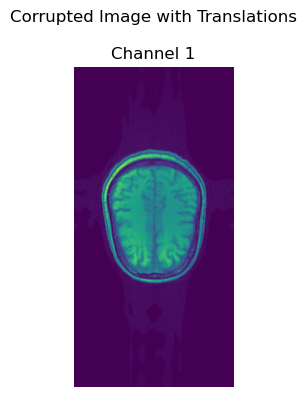

In [3]:
from utils.createArtifacts import randomTranslation_3D

# Create corrupted image with random translations
img_corrupted, t_n, masks = randomTranslation_3D(img_cplx, device = device, is_2D=True, sigma = 0.05, seed = 2)
kspace_corrupted = fftnc(img_corrupted, dims=(-4, -3, -2)).to(device)
# Calculate ESPIRiT maps from corrupted image
espirit_maps_corrupted = calc_espirit_maps(to_espirit_dims(kspace_corrupted), acs = 48, kernel_width=12, sp_device = sp_device)
espirit_maps_corrupted = from_espirit_dims(espirit_maps_corrupted)

# Show corrupted image
p_corrupted = torch.sum(img_corrupted*espirit_maps_corrupted.conj(), dim=-1)
show_slice(p_corrupted, max_images=1, headline="Corrupted Image with Translations")


In [4]:
print("Translations (z,y,x): ", t_n)

Translations (z,y,x):  tensor([[0.0213, 0.0415, 0.0000],
        [0.0143, 0.0409, 0.0000],
        [0.0339, 0.0222, 0.0000],
        [0.0261, 0.0118, 0.0000],
        [0.0207, 0.0425, 0.0000]], device='cuda:0')


In [5]:
print("kspace_corrupted shape:", kspace_corrupted.shape)
print("espirit_maps_corrupted shape:", espirit_maps_corrupted.shape)
print(p_true.device)

kspace_corrupted shape: torch.Size([640, 320, 1, 20])
espirit_maps_corrupted shape: torch.Size([640, 320, 1, 20])
cuda:0


In [6]:
from utils.EHE import EH, EHE
iterations = 5
b = EH(kspace_corrupted, t_n = t_n, iterations = iterations, masks= masks, sigmas = espirit_maps, image_shape = image_shape)
EHEp = EHE(p_true, t_n = t_n, iterations = iterations, masks= masks, sigmas = espirit_maps, image_shape = image_shape)

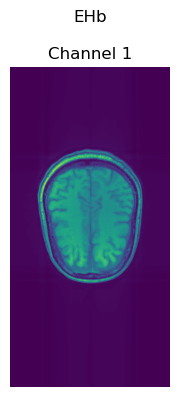

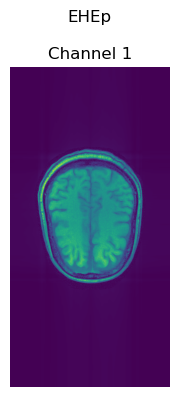

In [7]:
show_slice(b.view(640,320,1), max_images=1, headline="EHb")
show_slice(EHEp.view(640,320,1), max_images=1, headline="EHEp")

In [8]:
# the regularization term
lambda_ = 1e-3

lambda_scaled = lambda_ * torch.norm(b, p=2)
print(lambda_scaled.shape)


x0 = torch.zeros_like(b, device=device, dtype=torch.complex64)
eye = torch.ones_like(b, device=device, dtype=torch.complex64)

A = EHE(eye, t_n=t_n, iterations=iterations, masks=masks, sigmas=espirit_maps, image_shape=image_shape) 
M_inv = (1.0 / (A + lambda_scaled))*lambda_
""" eye = torch.ones_like(b, device=device, dtype=torch.float32)
_lambda = torch.complex(eye, eye) * lambda_scaled
A = A + _lambda """



torch.Size([])


' eye = torch.ones_like(b, device=device, dtype=torch.float32)\n_lambda = torch.complex(eye, eye) * lambda_scaled\nA = A + _lambda '

In [9]:
from utils.conjugate_gradient import my_cg



x_rec, info = my_cg(A, b, x0, max_iter=1000, tol=1e-2, regularisation=lambda_scaled)



Iteration: 0 Residual: tensor(14.7135, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 10 Residual: tensor(18.8566, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 20 Residual: tensor(51.9478, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 30 Residual: tensor(83.8240, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 40 Residual: tensor(115.8167, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 50 Residual: tensor(148.3919, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 60 Residual: tensor(181.6328, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 70 Residual: tensor(215.5009, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 80 Residual: tensor(249.9243, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 90 Residual: tensor(284.8282, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
Iteration: 100 Residual: tensor(320.1441, device='cuda:

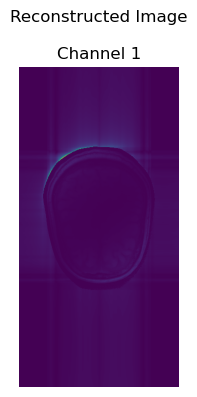

In [10]:
show_slice(x_rec.view(640,320,1), max_images=1, headline="Reconstructed Image")
x_rec = x_rec.view(nY, nX, 1)
#safe image
x_rec_np = x_rec.detach().cpu().numpy()
#as png
import matplotlib.pyplot as plt
plt.imsave("reconstructed_image.png", np.abs(x_rec_np[:,:,0]))